In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv('fifa21 raw data v2.csv', low_memory=False)
print(df[['Height', 'Weight', 'Value', 'Wage', 'Release Clause', 'Hits']].head())

  Height Weight    Value   Wage Release Clause Hits
0  170cm   72kg  €103.5M  €560K        €138.4M  771
1  187cm   83kg     €63M  €220K         €75.9M  562
2  188cm   87kg    €120M  €125K        €159.4M  150
3  181cm   70kg    €129M  €370K          €161M  207
4  175cm   68kg    €132M  €270K        €166.5M  595


In [ ]:
# ===================================
# Question 1: Convert the height and weight columns to numerical forms
# ===================================

# Before cleaning
print("Before cleaning:")
print(df['Height'].head())

# Strip 'cm' or inches from the string and convert to integer
def clean_height(x):
    if isinstance(x, str):
        if 'cm' in x:
            return int(x.replace('cm', ''))
        if "'" in x:  # Format like 6'1"
            feet, inches = x.split("'")
            inches = inches.replace('"', '')
            # Convert feet and inches to cm
            total_inches = int(feet) * 12 + int(inches)
            return round(total_inches * 2.54)
    return x

# Apply it to the dataframe
df['Height'] = df['Height'].apply(clean_height)

# After cleaning
print("\nAfter cleaning:")
print(df['Height'].head())
print("\nColumn Data Type:", df['Height'].dtype)

Before cleaning:
0    170cm
1    187cm
2    188cm
3    181cm
4    175cm
Name: Height, dtype: str

After cleaning:
0    170
1    187
2    188
3    181
4    175
Name: Height, dtype: int64

Column Data Type: int64


In [ ]:
# ===================================
# Question 2: Remove the unnecessary newline characters from all columns that have them.
# ===================================

# Remove the newline characters from all columns that have them.
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].str.replace('\n', '')
        df[col] = df[col].str.strip()

In [ ]:
# ===================================
# Question 3: Based on the 'Joined' column, check which players have been playing at a club for more than 10 years!
# ===================================

df['Joined'] = pd.to_datetime(df['Joined'])
df['Years_at_Club'] = 2021 - df['Joined'].dt.year # 2021 Because the dataset is from FIFA 21, so we can assume the data is from around that time.

# Filter for loyal players
loyal_players = df[df['Years_at_Club'] > 10]
print(loyal_players[['Name', 'Club', 'Years_at_Club']].head())

            Name                       Club  Years_at_Club
0       L. Messi       \n\n\n\nFC Barcelona             17
15    K. Benzema        \n\n\n\nReal Madrid             12
16  Sergio Ramos        \n\n\n\nReal Madrid             16
23       H. Kane  \n\n\n\nTottenham Hotspur             11
39  G. Chiellini           \n\n\n\nJuventus             16


In [ ]:
# ===================================
# Question 4: 'Value', 'Wage' and "Release Clause' are string columns. Convert them to numbers. For eg, "M" 
# in value column is Million, so multiply the row values by 1,000,000, etc.
# ===================================

print("\nBefore cleaning financial columns:")
print(df[['Value', 'Wage', 'Release Clause']].head())

def clean_currency(x):
    if isinstance(x, str):
        x = x.replace('€', '')
        if 'M' in x:
            return float(x.replace('M', '')) * 1000000
        elif 'K' in x:
            return float(x.replace('K', '')) * 1000
        return float(x)
    return x

# Run this function on all three financial columns
for col in ['Value', 'Wage', 'Release Clause']:
    df[col] = df[col].apply(clean_currency)

print("\nAfter cleaning financial columns:")
print(df[['Value', 'Wage', 'Release Clause']].head())


Before cleaning financial columns:
     Value   Wage Release Clause
0  €103.5M  €560K        €138.4M
1     €63M  €220K         €75.9M
2    €120M  €125K        €159.4M
3    €129M  €370K          €161M
4    €132M  €270K        €166.5M

After cleaning financial columns:
         Value      Wage  Release Clause
0  103500000.0  560000.0     138400000.0
1   63000000.0  220000.0      75900000.0
2  120000000.0  125000.0     159400000.0
3  129000000.0  370000.0     161000000.0
4  132000000.0  270000.0     166500000.0


In [ ]:
# ===================================
# Question 5: Some columns have 'star' characters. Strip those columns of these stars and make the columns numerical
# ===================================

print("\nBefore cleaning W/F column:")
print(df['W/F'].head())

df['W/F'] = df['W/F'].str.replace('★', '').str.strip().astype(int)

print("\nAfter cleaning W/F column:")
print(df['W/F'].head())


Before cleaning W/F column:
0    4 ★
1    4 ★
2    3 ★
3    5 ★
4    5 ★
Name: W/F, dtype: str

After cleaning W/F column:
0    4
1    4
2    3
3    5
4    5
Name: W/F, dtype: int64


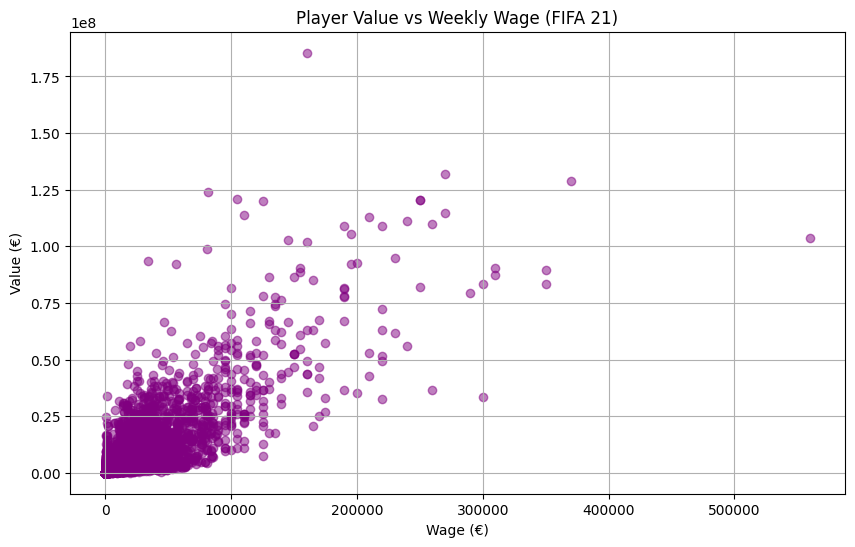

In [ ]:
# ===================================
# Question 6: Which players are highly valuable but still underpaid (on low wages)? (hint: scatter plot between wage and value)
# ===================================

plt.figure(figsize=(10, 6))
plt.scatter(df['Wage'], df['Value'], alpha=0.5, color='purple')
plt.title('Player Value vs Weekly Wage (FIFA 21)')
plt.xlabel('Wage (€)')
plt.ylabel('Value (€)')
plt.grid(True)
plt.show()